In [ ]:
# ============================================================
# AI-Powered Book Recommendation System
# Notebook 4 : Content-Based Recommendation
#
# This notebook builds a content-based recommendation model
# using TF-IDF Vectorization and Cosine Similarity.
# ============================================================

In [ ]:
# ============================================================
# Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pickle
import re
pd.set_option("display.max_columns", None)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = "/content/drive/MyDrive/BookVerse/datasets/books_cleaned.csv"
books = pd.read_csv(path)

In [ ]:
exclude_patterns = (
    r"box ?set|boxed ?set|boxset|boxedset|"
    r"collection|complete collection|"
    r"omnibus|gift set|"
    r"slipcase|companion|"
    r"guide|study guide|summary|analysis|"
    r"illustrated|calendar|journal|"
    r"workbook|coloring|encyclopedia|"
    r"sampler|preview|excerpt|"
    r"collector'?s edition|"
    r"special edition|"
    r"deluxe edition|"
    r"anniversary edition"
)
books["is_main_book"] = ~books["title"].str.contains(
    exclude_patterns,
    case=False,
    na=False,
    regex=True
)

print("Main Books:", books["is_main_book"].sum())
print("Filtered Editions:", (~books["is_main_book"]).sum())

Main Books: 41524
Filtered Editions: 785


In [ ]:
books.fillna({
    "title": "",
    "author": "",
    "series": "",
    "genres": "",
    "description": "",
    "publisher": "",
    "language": "Unknown",
    "likedPercent": 0,
    "coverImg": "No Cover"
}, inplace=True)

In [ ]:
books.isnull().sum()

,0
bookId,0
title,0
author,0
series,0
genres,0
description,0
publisher,0
language,0
rating,0
numRatings,0


In [ ]:
print(f"Number of Books   : {books.shape[0]}")
print(f"Number of Features: {books.shape[1]}")

Number of Books   : 42309
Number of Features: 14


In [ ]:
books.head()

,bookId,title,author,series,genres,description,publisher,language,rating,numRatings,likedPercent,coverImg,combined_features,is_main_book
0,2767052-the-hunger-games,the hunger games,suzanne collins,the hunger games,"['young adult', 'fiction', 'dystopia', 'fantas...",winning means fame and fortune losing means ce...,scholastic press,English,4.33,6376780,96.0,https://i.gr-assets.com/images/S/compressed.ph...,"['young adult', 'fiction', 'dystopia', 'fantas...",True
1,2.Harry_Potter_and_the_Order_of_the_Phoenix,harry potter and the order of the phoenix,j k rowling mary grandpr illustrator,harry potter,"['fantasy', 'young adult', 'fiction', 'magic',...",there is a door at the end of a silent corrido...,scholastic inc,English,4.50,2507623,98.0,https://i.gr-assets.com/images/S/compressed.ph...,"['fantasy', 'young adult', 'fiction', 'magic',...",True
2,2657.To_Kill_a_Mockingbird,to kill a mockingbird,harper lee,to kill a mockingbird,"['classics', 'fiction', 'historical fiction', ...",the unforgettable novel of a childhood in a sl...,harper perennial modern classics,English,4.28,4501075,95.0,https://i.gr-assets.com/images/S/compressed.ph...,"['classics', 'fiction', 'historical fiction', ...",True
3,1885.Pride_and_Prejudice,pride and prejudice,jane austen anna quindlen introduction,,"['classics', 'fiction', 'romance', 'historical...",alternate cover edition of isbn since its imme...,modern library,English,4.26,2998241,94.0,https://i.gr-assets.com/images/S/compressed.ph...,"['classics', 'fiction', 'romance', 'historical...",True
4,41865.Twilight,twilight,stephenie meyer,the twilight saga,"['young adult', 'fantasy', 'romance', 'vampire...",about three things i was absolutely positive f...,little brown and company,English,3.60,4964519,78.0,https://i.gr-assets.com/images/S/compressed.ph...,"['young adult', 'fantasy', 'romance', 'vampire...",True


In [ ]:
print("Combined Features Available:",
      "combined_features" in books.columns)
books[["title", "combined_features"]].head()

Combined Features Available: True


,title,combined_features
0,the hunger games,"['young adult', 'fiction', 'dystopia', 'fantas..."
1,harry potter and the order of the phoenix,"['fantasy', 'young adult', 'fiction', 'magic',..."
2,to kill a mockingbird,"['classics', 'fiction', 'historical fiction', ..."
3,pride and prejudice,"['classics', 'fiction', 'romance', 'historical..."
4,twilight,"['young adult', 'fantasy', 'romance', 'vampire..."


In [ ]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=50000,
    min_df=2,
    max_df=0.85,
    ngram_range=(1,2),
    sublinear_tf=True
)

In [ ]:
tfidf_matrix = tfidf.fit_transform(books["combined_features"])

In [ ]:
print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (42309, 50000)


In [ ]:
print(type(tfidf_matrix))

<class 'scipy.sparse._csr.csr_matrix'>


In [ ]:
print("Vocabulary Size:", len(tfidf.vocabulary_))

Vocabulary Size: 50000


In [ ]:
books["combined_features"].sample(5, random_state=42).tolist()

["['historical fiction', 'childrens', 'fiction', 'historical', 'middle grade', 'young adult', 'chapter books', 'juvenile', 'realistic fiction', 'kids'] ['historical fiction', 'childrens', 'fiction', 'historical', 'middle grade', 'young adult', 'chapter books', 'juvenile', 'realistic fiction', 'kids'] ['historical fiction', 'childrens', 'fiction', 'historical', 'middle grade', 'young adult', 'chapter books', 'juvenile', 'realistic fiction', 'kids'] ['historical fiction', 'childrens', 'fiction', 'historical', 'middle grade', 'young adult', 'chapter books', 'juvenile', 'realistic fiction', 'kids'] ['historical fiction', 'childrens', 'fiction', 'historical', 'middle grade', 'young adult', 'chapter books', 'juvenile', 'realistic fiction', 'kids'] kit longs for a big story to write in her daily newspaper for her dad that is until she s faced with news that s really bad when mother s friends lose their house and come to stay with her family it s nothing but trouble for kit then kit s dad lose

In [ ]:
print(tfidf.get_feature_names_out()[:100])

['12th' '12th century' '13th' '13th century' '14th' '14th century' '15th'
 '15th century' '16th' '16th century' '17th' '17th century' '18th'
 '18th century' '19th' '19th century' '1st' '1st grade' '20th'
 '20th century' '21st' '21st century' '2nd' '2nd grade' '40k'
 '40k fiction' 'aang' 'aaron' 'ab' 'ab lard' 'abandon' 'abandoned'
 'abandoned child' 'abandoned family' 'abandoned house' 'abandoned mother'
 'abandoned years' 'abandoning' 'abandonment' 'abandons' 'abba' 'abbess'
 'abbey' 'abbi' 'abbi glines' 'abbie' 'abbot' 'abbott' 'abby' 'abc' 'abd'
 'abduct' 'abducted' 'abduction' 'abductions' 'abductor' 'abdul'
 'abdullah' 'abe' 'abel' 'aber' 'abhorrent' 'abhorsen' 'abide' 'abiding'
 'abiding love' 'abigail' 'abilities' 'ability' 'ability communicate'
 'ability control' 'ability make' 'ability read' 'ability turn' 'abject'
 'ablaze' 'able' 'able break' 'able bring' 'able convince' 'able escape'
 'able forget' 'able help' 'able live' 'able love' 'able make'
 'able overcome' 'able prote

In [ ]:
feature_names = tfidf.get_feature_names_out()

In [ ]:
print(len(tfidf.vocabulary_))

50000


In [ ]:
density = tfidf_matrix.nnz / (
    tfidf_matrix.shape[0] *
    tfidf_matrix.shape[1]
)

print(f"Matrix Density: {density:.6f}")

Matrix Density: 0.001894


In [ ]:
feature_names = tfidf.get_feature_names_out()
print("First 20 Features:")
print(feature_names[:20])

First 20 Features:
['12th' '12th century' '13th' '13th century' '14th' '14th century' '15th'
 '15th century' '16th' '16th century' '17th' '17th century' '18th'
 '18th century' '19th' '19th century' '1st' '1st grade' '20th'
 '20th century']


In [ ]:
print("Number of Features:", len(feature_names))
print("Number of Books:", tfidf_matrix.shape[0])

Number of Features: 50000
Number of Books: 42309


In [ ]:
feature_counts = np.asarray(
    tfidf_matrix.sum(axis=0)
).flatten()

In [ ]:
top_indices = feature_counts.argsort()[-20:]

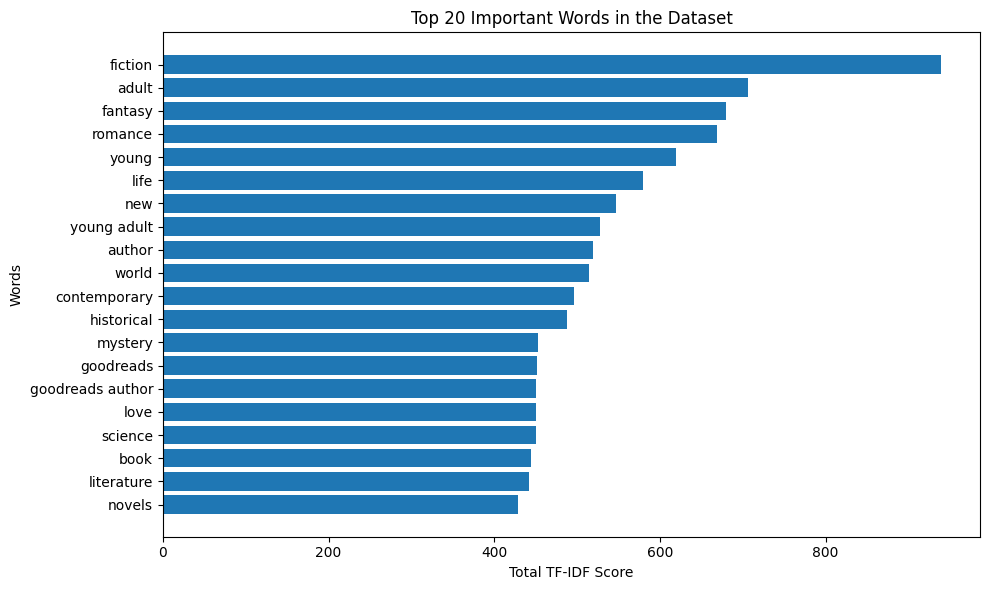

In [ ]:
plt.figure(figsize=(10,6))
plt.barh(
    feature_names[top_indices],
    feature_counts[top_indices]
)
plt.title("Top 20 Important Words in the Dataset")
plt.xlabel("Total TF-IDF Score")
plt.ylabel("Words")
plt.tight_layout()
plt.show()

In [ ]:
books["display_title"] = (
    books["title"] +
    " — " +
    books["author"]
)

In [ ]:
indices = pd.Series(books.index,index=books["display_title"])

In [ ]:
print(indices.index.duplicated().sum())

0


In [ ]:
import re
from sklearn.metrics.pairwise import cosine_similarity

def recommend_books(book_title, top_n=10):

    if book_title not in indices:
        raise ValueError(f"Book '{book_title}' not found.")

    idx = indices[book_title]
    similarity_scores = cosine_similarity(
        tfidf_matrix[idx],
        tfidf_matrix
    ).flatten()
    similar_indices = similarity_scores.argsort()[::-1][:300]
    exclude_patterns = (
        r"box set|boxed set|collection|complete collection|"
        r"omnibus|gift set|slipcase|companion|"
        r"guide|study guide|summary|analysis|"
        r"illustrated|calendar|journal|"
        r"workbook|coloring|encyclopedia|"
        r"companion guide|notes"
    )
    recommendations = []
    seen_titles = set()
    author_count = {}

    for i in similar_indices:
        if i == idx:
            continue

        row = books.iloc[i]

        title = str(row["title"])
        author = str(row["author"])
        if not row["is_main_book"]:
            continue

        normalized_title = re.sub(
            exclude_patterns,
            "",
            title.lower(),
            flags=re.IGNORECASE
        )
        normalized_title = re.sub(
            r"\s+",
            " ",
            normalized_title
        ).strip()

        if normalized_title in seen_titles:
            continue

        seen_titles.add(normalized_title)

        if author_count.get(author, 0) >= 2:
            continue

        author_count[author] = author_count.get(author, 0) + 1
        recommendations.append({

            "title": title,
            "author": author,
            "genres": row["genres"],
            "rating": row["rating"],
            "Similarity Score": round(float(similarity_scores[i]), 4)

        })
        if len(recommendations) >= top_n:
            break
    return pd.DataFrame(recommendations)

Total Scores: 7958753

Minimum : 0.00014020141321732714
Maximum : 0.8667920477854962
Mean    : 0.015374662070235563
Median  : 0.011839857746787155

Percentiles
25% : 0.0060522527270420465
50% : 0.011839857746787155
75% : 0.020316008435441183
90% : 0.03160106456609733
95% : 0.040954784299465447
99% : 0.06628342378746252


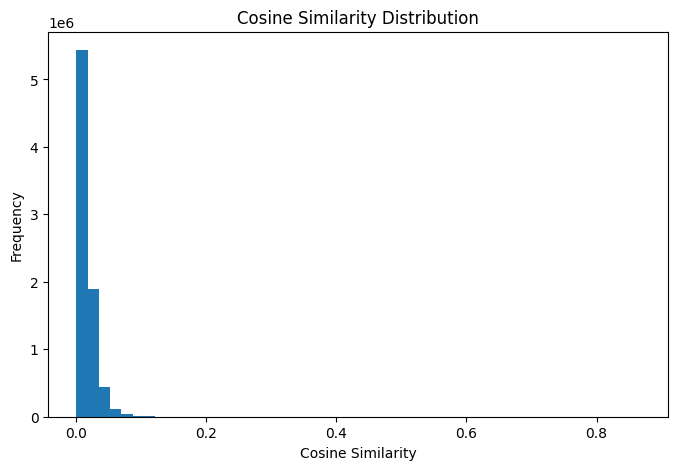

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

all_scores = []
sample_books = books["display_title"].dropna().sample(
    min(200, len(books)),
    random_state=42
)

for title in sample_books:
    if title not in indices:
        continue

    idx = indices[title]
    scores = cosine_similarity(
        tfidf_matrix[idx],
        tfidf_matrix
    ).flatten()

    scores = scores[scores < 0.9999]
    scores = scores[scores > 0]
    all_scores.extend(scores)
all_scores = np.array(all_scores)
print("Total Scores:", len(all_scores))
print()
print("Minimum :", np.min(all_scores))
print("Maximum :", np.max(all_scores))
print("Mean    :", np.mean(all_scores))
print("Median  :", np.median(all_scores))
print("\nPercentiles")
for p in [25,50,75,90,95,99]:
    print(f"{p}% :", np.percentile(all_scores,p))

plt.figure(figsize=(8,5))
plt.hist(all_scores, bins=50)
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.title("Cosine Similarity Distribution")
plt.show()

In [ ]:
import pandas as pd
pd.set_option('display.max_colwidth',None)

books[
    books["display_title"].str.contains(
        "red rising",
        case=False,
        na=False
    )
]["display_title"]

,display_title
731,red rising — pierce brown goodreads author


In [ ]:
test_books = [
    "the hunger games — suzanne collins",
    "the silent patient — alex michaelides goodreads author",
    "divergent — veronica roth goodreads author",
    "red rising — pierce brown goodreads author"
]

for book in test_books:
    print(book)
    display(recommend_books(book))

the hunger games — suzanne collins


,title,author,genres,rating,Similarity Score
0,catching fire,suzanne collins,"['young adult', 'dystopia', 'fiction', 'fantas...",4.29,0.3702
1,mockingjay,suzanne collins,"['young adult', 'dystopia', 'fiction', 'fantas...",4.04,0.3434
2,divergent,veronica roth goodreads author,"['young adult', 'dystopia', 'fiction', 'fantas...",4.19,0.1625
3,arena one slaverunners,morgan rice goodreads author,"['dystopia', 'young adult', 'post apocalyptic'...",3.37,0.1549
4,insurgent,veronica roth goodreads author,"['young adult', 'dystopia', 'fiction', 'fantas...",4.02,0.1493
5,the maze runner series the maze runner,james dashner goodreads author,"['fiction', 'young adult', 'science fiction', ...",4.20,0.1449
6,relic,heather terrell goodreads author,"['young adult', 'dystopia', 'fantasy', 'scienc...",3.29,0.1367
7,the maze runner trilogy maze runner,james dashner goodreads author,"['young adult', 'dystopia', 'fiction', 'fantas...",4.19,0.1363
8,legend,marie lu goodreads author,"['young adult', 'dystopia', 'science fiction',...",4.17,0.1357
9,ruins,dan wells goodreads author,"['young adult', 'dystopia', 'science fiction',...",4.05,0.1353


the silent patient — alex michaelides goodreads author


,title,author,genres,rating,Similarity Score
0,a house without windows,stevie turner goodreads author,"['mystery', 'thriller', 'mystery thriller', 'f...",3.62,0.1458
1,the wife between us,greer hendricks goodreads author sarah pekkane...,"['thriller', 'fiction', 'mystery', 'mystery th...",3.84,0.1454
2,the ex wife,jess ryder,"['thriller', 'mystery', 'psychological thrille...",4.09,0.1368
3,behind closed doors,b a paris goodreads author,"['thriller', 'fiction', 'mystery', 'suspense',...",3.95,0.1368
4,then she was gone,lisa jewell goodreads author,"['mystery', 'thriller', 'fiction', 'mystery th...",4.03,0.1364
5,i let you go,clare mackintosh goodreads author,"['mystery', 'thriller', 'fiction', 'mystery th...",4.06,0.1339
6,i can be a better you,tarryn fisher goodreads author,"['thriller', 'contemporary', 'dark', 'new adul...",4.04,0.1237
7,the good widow,liz fenton goodreads author lisa steinke goodr...,"['mystery', 'thriller', 'fiction', 'suspense',...",3.76,0.1234
8,hush,anne frasier goodreads author,"['mystery', 'thriller', 'fiction', 'suspense',...",4.05,0.1234
9,sometimes i lie,alice feeney goodreads author,"['thriller', 'mystery', 'fiction', 'mystery th...",3.82,0.1230


divergent — veronica roth goodreads author


,title,author,genres,rating,Similarity Score
0,insurgent,veronica roth goodreads author,"['young adult', 'dystopia', 'fiction', 'fantas...",4.02,0.3418
1,free four tobias tells the divergent knife thr...,veronica roth goodreads author,"['young adult', 'dystopia', 'short stories', '...",4.15,0.2595
2,inside divergent the initiate s world,veronica roth goodreads author cecilia bernard,"['dystopia', 'science fiction', 'young adult',...",4.36,0.1850
3,catching fire,suzanne collins,"['young adult', 'dystopia', 'fiction', 'fantas...",4.29,0.1846
4,mockingjay,suzanne collins,"['young adult', 'dystopia', 'fiction', 'fantas...",4.04,0.1671
5,allegiant the ultimate interactive quiz book d...,sarah davids goodreads author,"['dystopia', 'young adult', 'action', 'science...",4.11,0.1637
6,divergent parody detergent,reid mockery,"['fantasy', 'young adult', 'dystopia', 'fictio...",3.95,0.1350
7,outside in,maria v snyder goodreads author,"['young adult', 'dystopia', 'science fiction',...",3.83,0.1217
8,the compound,s a bodeen goodreads author,"['young adult', 'science fiction', 'dystopia',...",3.88,0.1115
9,independent study,joelle charbonneau am lie sarn translator,"['dystopia', 'young adult', 'science fiction',...",3.97,0.1083


red rising — pierce brown goodreads author


,title,author,genres,rating,Similarity Score
0,golden son,pierce brown goodreads author,"['science fiction', 'fantasy', 'dystopia', 'fi...",4.44,0.2661
1,morning star,pierce brown goodreads author,"['science fiction', 'fantasy', 'fiction', 'dys...",4.49,0.1653
2,the empress,s j kincaid goodreads author,"['science fiction', 'young adult', 'fantasy', ...",3.84,0.1256
3,red queen,victoria aveyard goodreads author,"['fantasy', 'young adult', 'dystopia', 'romanc...",4.04,0.1239
4,noughts crosses,malorie blackman goodreads author,"['young adult', 'romance', 'fiction', 'dystopi...",4.23,0.1228
5,green mars,kim stanley robinson,"['science fiction', 'fiction', 'hugo awards', ...",3.94,0.1121
6,the song rising,samantha shannon goodreads author,"['fantasy', 'young adult', 'dystopia', 'fictio...",4.16,0.1111
7,aurora,kim stanley robinson,"['science fiction', 'fiction', 'space opera', ...",3.75,0.1094
8,epic,conor kostick goodreads author,"['science fiction', 'fantasy', 'young adult', ...",3.95,0.1093
9,starsight,brandon sanderson goodreads author,"['science fiction', 'young adult', 'fantasy', ...",4.44,0.1080


In [ ]:
search_books = books[
    [
        "bookId",
        "title",
        "author",
        "display_title"
    ]
]
search_books.to_csv(
    "/content/drive/MyDrive/BookVerse/models/search_books.csv",
    index=False
)

In [ ]:
books.to_csv(
    "/content/drive/MyDrive/BookVerse/models/books_final.csv",
    index=False
)


In [ ]:
import pickle
with open("/content/drive/MyDrive/BookVerse/models/tfidf_matrix.pkl", "wb") as f:
    pickle.dump(tfidf_matrix, f)

with open("/content/drive/MyDrive/BookVerse/models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

with open("/content/drive/MyDrive/BookVerse/models/book_indices.pkl", "wb") as f:
    pickle.dump(indices, f)
